# Tarea 05
* Nombre: Christopher Pulupa
* LINK REPOSITORIO: https://github.com/Mateosky1/Tarea05

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# Configuración visual para las gráficas
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

* 1.Cálculo de $p_2$ para $f(x)=-x^{3}-\cos(x)$ y análisis matemático del punto $p_{0}=0$.

In [2]:
def f1(x): return -x**3 - np.cos(x)
def df1(x): return -3*x**2 + np.sin(x)

# Newton paso a paso desde p0 = -1
p0 = -1.0
p1_newton = p0 - f1(p0)/df1(p0)
p2_newton = p1_newton - f1(p1_newton)/df1(p1_newton)
print(f"Método de Newton: p2 = {p2_newton:.6f}")

# Secante paso a paso. Requiere dos puntos, asumimos un p1 cercano a p0.
p1_secante = -0.9 # Pequeño desplazamiento
p2_secante = p1_secante - f1(p1_secante) * (p1_secante - p0) / (f1(p1_secante) - f1(p0))
print(f"Método de la Secante: p2 = {p2_secante:.6f}")

# Análisis de p0 = 0 para Newton
print(f"Derivada evaluada en p0=0: {df1(0.0)}") 
print("¿Se podría usar p0 = 0? No, porque la derivada se vuelve 0 y el algoritmo de Newton arrojaría una división por cero.")

Método de Newton: p2 = -0.865684
Método de la Secante: p2 = -0.869518
Derivada evaluada en p0=0: 0.0
¿Se podría usar p0 = 0? No, porque la derivada se vuelve 0 y el algoritmo de Newton arrojaría una división por cero.


* 2.Encontrar soluciones con tolerancia de $10^{-4}$. Al pasar fprime, optimize.newton utiliza el método de Newton de manera estricta.

In [3]:
# Lista de tuplas: (función, derivada, punto inicial x0, nombre)
funcs2 = [
    (lambda x: x**3 - 2*x**2 - 5, lambda x: 3*x**2 - 4*x, 2.5, "a"),
    (lambda x: x**3 + 3*x**2 - 1, lambda x: 3*x**2 + 6*x, -2.5, "b"),
    (lambda x: x - np.cos(x), lambda x: 1 + np.sin(x), 0.5, "c"),
    (lambda x: x - 0.8 - 0.2*np.sin(x), lambda x: 1 - 0.2*np.cos(x), 0.5, "d")
]

print("--- Ejercicio 2 (Tolerancia 1e-4) ---")
for f, df, x0, name in funcs2:
    root, info = optimize.newton(f, x0, fprime=df, tol=1e-4, full_output=True)
    print(f"Ecuación {name}: Raíz = {root:.6f} (encontrada en {info.iterations} iteraciones)")

--- Ejercicio 2 (Tolerancia 1e-4) ---
Ecuación a: Raíz = 2.690647 (encontrada en 4 iteraciones)
Ecuación b: Raíz = -2.879385 (encontrada en 5 iteraciones)
Ecuación c: Raíz = 0.739085 (encontrada en 3 iteraciones)
Ecuación d: Raíz = 0.964334 (encontrada en 3 iteraciones)


* 3.Comparación de métodos usando una tolerancia de $10^{-5}$ para $1\le x\le2$.

In [4]:
def f3a(x): return 3*x - np.exp(x)
def df3a(x): return 3 - np.exp(x)

def f3b(x): return 2*x + 3*np.cos(x) - np.exp(x)
def df3b(x): return 2 - 3*np.sin(x) - np.exp(x)

x0 = 1.5 # Tomamos el punto medio del intervalo [1, 2] como estimación inicial

print("--- Ejercicio 3 (Tolerancia 1e-5) ---")
for name, f, df in [("3a", f3a, df3a), ("3b", f3b, df3b)]:
    # Newton: enviamos la derivada
    root_n, info_n = optimize.newton(f, x0, fprime=df, tol=1e-5, full_output=True)
    # Secante: omitimos la derivada
    root_s, info_s = optimize.newton(f, x0, tol=1e-5, full_output=True)
    
    print(f"Ecuación {name}:")
    print(f"  Newton  -> Raíz = {root_n:.6f} | Iteraciones = {info_n.iterations}")
    print(f"  Secante -> Raíz = {root_s:.6f} | Iteraciones = {info_s.iterations}")

--- Ejercicio 3 (Tolerancia 1e-5) ---
Ecuación 3a:
  Newton  -> Raíz = 1.512135 | Iteraciones = 3
  Secante -> Raíz = 1.512135 | Iteraciones = 3
Ecuación 3b:
  Newton  -> Raíz = 1.239715 | Iteraciones = 4
  Secante -> Raíz = 1.239715 | Iteraciones = 5


* 4.Aproximación de raíces polinomiales usando puntos y métodos específicos. Empleamos root_scalar para el método de la secante ya que permite pasar estrictamente los dos extremos iniciales.

In [5]:
def f4(x): return 230*x**4 + 18*x**3 + 9*x**2 - 221*x - 9
def df4(x): return 920*x**3 + 54*x**2 + 18*x - 221

print("--- Ejercicio 4 ---")
# a. Secante (usando extremos como x0 y x1)
sec_neg = optimize.root_scalar(f4, method='secant', x0=-1.0, x1=0.0, xtol=1e-6)
sec_pos = optimize.root_scalar(f4, method='secant', x0=0.0, x1=1.0, xtol=1e-6)
print(f"Secante [-1, 0]: Raíz = {sec_neg.root:.6f} | Iteraciones = {sec_neg.iterations}")
print(f"Secante [0, 1] : Raíz = {sec_pos.root:.6f} | Iteraciones = {sec_pos.iterations}")

# b. Newton (usando puntos medios)
newt_neg, info_nn = optimize.newton(f4, -0.5, fprime=df4, tol=1e-6, full_output=True)
newt_pos, info_np = optimize.newton(f4, 0.5, fprime=df4, tol=1e-6, full_output=True)
print(f"Newton (inicio en -0.5): Raíz = {newt_neg:.6f} | Iteraciones = {info_nn.iterations}")
print(f"Newton (inicio en 0.5) : Raíz = {newt_pos:.6f} | Iteraciones = {info_np.iterations}")

--- Ejercicio 4 ---
Secante [-1, 0]: Raíz = -0.040659 | Iteraciones = 5
Secante [0, 1] : Raíz = -0.040659 | Iteraciones = 11
Newton (inicio en -0.5): Raíz = -0.040659 | Iteraciones = 4
Newton (inicio en 0.5) : Raíz = -0.040659 | Iteraciones = 6


* 5.Aplicación iterativa manual para controlar y visualizar exactamente las 10 iteraciones requeridas de $f(x)=\tan(\pi x)-6$.

In [6]:
def f5(x): return np.tan(np.pi * x) - 6
def df5(x): return np.pi / (np.cos(np.pi * x)**2)

print("--- Ejercicio 5 (Exactamente 10 iteraciones) ---")

# a. Bisección
a, b = 0.0, 0.48
for _ in range(10):
    c = (a + b) / 2
    if f5(a) * f5(c) < 0: b = c
    else: a = c
print(f"Bisección: {c:.6f}")

# b. Newton (Evitamos p0=0 por salto enorme fuera de periodo; usamos p1=0.48)
p_n = 0.48
for _ in range(10):
    p_n = p_n - f5(p_n) / df5(p_n)
print(f"Newton (desde 0.48): {p_n:.6f}")

# c. Secante
p_s0, p_s1 = 0.0, 0.48
for _ in range(10):
    p_s2 = p_s1 - f5(p_s1) * (p_s1 - p_s0) / (f5(p_s1) - f5(p_s0))
    p_s0, p_s1 = p_s1, p_s2
print(f"Secante: {p_s1:.6f}")

print("\nAnálisis de eficacia:")
print("El método de Newton es el más eficaz porque utiliza información de la tangente (derivada) para converger cuadráticamente hacia la raíz exacta (~0.4474), logrando mucha mayor precisión en las mismas 10 iteraciones en comparación a la reducción lineal de la bisección.")

--- Ejercicio 5 (Exactamente 10 iteraciones) ---
Bisección: 0.447656
Newton (desde 0.48): 0.447432
Secante: -2989.940038

Análisis de eficacia:
El método de Newton es el más eficaz porque utiliza información de la tangente (derivada) para converger cuadráticamente hacia la raíz exacta (~0.4474), logrando mucha mayor precisión en las mismas 10 iteraciones en comparación a la reducción lineal de la bisección.


* 6.Visualización gráfica y localización de múltiples ceros.

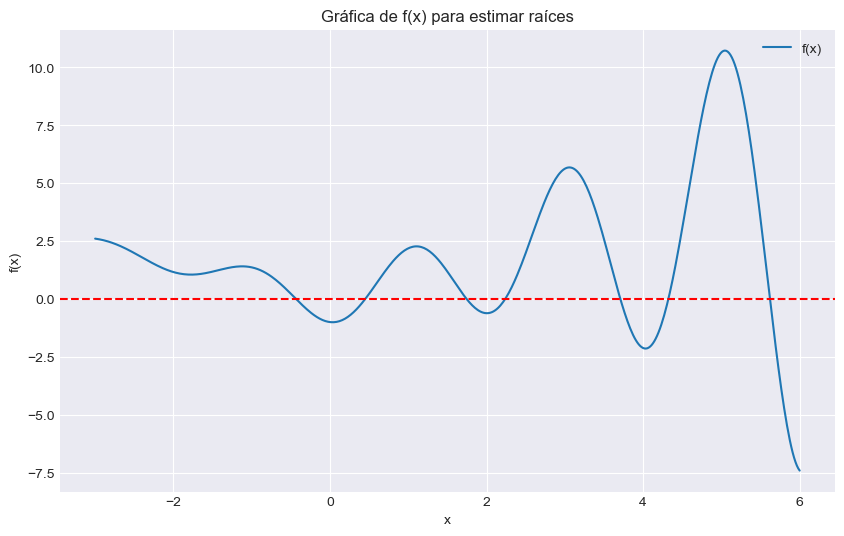

a. Único cero negativo: -0.434143
b. Cuatro primeros ceros positivos: [np.float64(0.450657), np.float64(1.744738), np.float64(2.23832), np.float64(3.709041)]
c. Aproximación razonable: Dado el término cos(πx), las raíces ocurren cerca de donde el coseno es 0, es decir x_n ≈ n - 0.5
d. Vigesimoquinto cero positivo (n=25): 24.499887


In [7]:
def f6(x): return np.log(x**2 + 1) - np.exp(0.4 * x) * np.cos(np.pi * x)

# Graficar f(x)
x_vals = np.linspace(-3, 6, 500)
plt.plot(x_vals, f6(x_vals), label='f(x)')
plt.axhline(0, color='red', linestyle='--')
plt.title('Gráfica de f(x) para estimar raíces')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

# a. Único cero negativo
raiz_neg = optimize.newton(f6, x0=-0.5, tol=1e-6)
print(f"a. Único cero negativo: {raiz_neg:.6f}")

# b. Cuatro ceros positivos más pequeños
ceros_pos = []
for i in range(4):
    # La gráfica y el término cos(pi*x) sugieren cruces cerca de n - 0.5
    estimacion = i + 0.5 
    raiz = optimize.newton(f6, x0=estimacion, tol=1e-6)
    ceros_pos.append(round(raiz, 6))
print(f"b. Cuatro primeros ceros positivos: {ceros_pos}")

# c y d. Enésimo cero positivo y vigesimoquinto cero
print("c. Aproximación razonable: Dado el término cos(πx), las raíces ocurren cerca de donde el coseno es 0, es decir x_n ≈ n - 0.5")
raiz_25 = optimize.newton(f6, x0=(25 - 0.5), tol=1e-6)
print(f"d. Vigesimoquinto cero positivo (n=25): {raiz_25:.6f}")

* 7.Comprobación de la divergencia con funciones problemáticas (raíz cúbica) analizando el historial iterativo.

In [8]:
# Usamos np.cbrt para soportar el paso por valores negativos sin error de dominio
def f7(x): return np.cbrt(x)
def df7(x): return 1.0 / (3.0 * np.cbrt(x)**2)

print("--- Ejercicio 7: Análisis de Divergencia ---")
# Newton desde x=1
p_newt = 1.0
print("Historial de Newton (p0=1):")
for i in range(5):
    print(f"  Iteración {i}: {p_newt}")
    p_newt = p_newt - f7(p_newt)/df7(p_newt)

# Secante desde p0=5, p1=0.5
p_s0, p_s1 = 5.0, 0.5
print("\nHistorial de la Secante (p0=5, p1=0.5):")
for i in range(5):
    print(f"  Iteración {i}: {p_s1}")
    p_s2 = p_s1 - f7(p_s1)*(p_s1 - p_s0)/(f7(p_s1) - f7(p_s0))
    p_s0, p_s1 = p_s1, p_s2

print("\nConclusión: Para la función raíz cúbica real centrada en cero, el método de Newton diverge fuertemente (cada iteración dobla la distancia a la raíz y cambia de signo). La secante también presenta comportamientos oscilatorios o de alejamiento debido a la tangente vertical en x=0.")

--- Ejercicio 7: Análisis de Divergencia ---
Historial de Newton (p0=1):
  Iteración 0: 1.0
  Iteración 1: -2.0
  Iteración 2: 3.9999999999999973
  Iteración 3: -7.999999999999994
  Iteración 4: 15.999999999999993

Historial de la Secante (p0=5, p1=0.5):
  Iteración 0: 0.5
  Iteración 1: -3.398011761822331
  Iteración 2: -0.8468509642591542
  Iteración 3: 3.484077330057768
  Iteración 4: 0.8173796732586709

Conclusión: Para la función raíz cúbica real centrada en cero, el método de Newton diverge fuertemente (cada iteración dobla la distancia a la raíz y cambia de signo). La secante también presenta comportamientos oscilatorios o de alejamiento debido a la tangente vertical en x=0.
